# Import Libraries

In [112]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('CVD.csv')
df

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,F,32.0,69.100,1.710,23.600,86.200,125/79,248.0,78.0,111.0,...,Low,N,171.000,0.504,125.0,79.0,Elevated,140.0,17.930,INTERMEDIARY
1,F,55.0,118.700,1.690,41.600,82.500,139/70,162.0,50.0,135.0,...,High,Y,169.000,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.510,HIGH
2,M,NaN,NaN,1.830,26.900,106.700,104/77,103.0,73.0,114.0,...,High,Y,183.000,0.583,104.0,77.0,Normal,0.0,12.640,INTERMEDIARY
3,M,44.0,108.300,1.800,33.400,96.600,140/83,134.0,46.0,91.0,...,High,Y,NaN,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.360,INTERMEDIARY
4,F,32.0,99.500,1.860,28.800,102.700,144/83,146.0,64.0,141.0,...,High,N,186.000,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.880,INTERMEDIARY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1524,F,40.0,72.070,1.889,NaN,95.326,119/66,157.0,60.0,93.0,...,Moderate,Y,188.894,0.505,119.0,66.0,Normal,67.0,14.300,LOW
1525,F,78.0,85.877,1.825,24.426,112.340,102/115,241.0,84.0,NaN,...,Low,N,182.485,0.616,102.0,115.0,Hypertension Stage 2,127.0,14.805,INTERMEDIARY
1526,M,39.0,98.626,1.521,20.055,77.193,150/90,237.0,82.0,147.0,...,High,N,152.119,0.507,150.0,90.0,Hypertension Stage 2,125.0,18.251,INTERMEDIARY
1527,M,71.0,116.163,1.841,29.279,114.197,112/63,193.0,84.0,123.0,...,High,Y,184.059,0.620,112.0,63.0,Normal,79.0,15.316,INTERMEDIARY


# Data Cleaning

## Check shape

In [113]:
df.shape

(1529, 22)

## Check for null values

In [114]:
df.isnull().sum().sort_values(ascending=False)

Diastolic BP                    82
Weight (kg)                     81
HDL (mg/dL)                     80
Waist-to-Height Ratio           79
Age                             78
Height (cm)                     74
Total Cholesterol (mg/dL)       73
Systolic BP                     71
CVD Risk Score                  70
Estimated LDL (mg/dL)           69
Fasting Blood Sugar (mg/dL)     67
Abdominal Circumference (cm)    67
Height (m)                      67
BMI                             64
Sex                              0
Family History of CVD            0
Diabetes Status                  0
Smoking Status                   0
Blood Pressure (mmHg)            0
Physical Activity Level          0
Blood Pressure Category          0
CVD Risk Level                   0
dtype: int64

In [115]:
(df.isnull().sum() / len(df)) * 100

Sex                             0.000000
Age                             5.101373
Weight (kg)                     5.297580
Height (m)                      4.381949
BMI                             4.185742
Abdominal Circumference (cm)    4.381949
Blood Pressure (mmHg)           0.000000
Total Cholesterol (mg/dL)       4.774362
HDL (mg/dL)                     5.232178
Fasting Blood Sugar (mg/dL)     4.381949
Smoking Status                  0.000000
Diabetes Status                 0.000000
Physical Activity Level         0.000000
Family History of CVD           0.000000
Height (cm)                     4.839765
Waist-to-Height Ratio           5.166776
Systolic BP                     4.643558
Diastolic BP                    5.362982
Blood Pressure Category         0.000000
Estimated LDL (mg/dL)           4.512753
CVD Risk Score                  4.578156
CVD Risk Level                  0.000000
dtype: float64

## Check for duplicates

In [116]:
df.duplicated().sum()

np.int64(0)

## Check for negative values

In [117]:
(df.select_dtypes(include='number') < 0).sum()

Age                              0
Weight (kg)                      0
Height (m)                       0
BMI                              0
Abdominal Circumference (cm)     0
Total Cholesterol (mg/dL)        0
HDL (mg/dL)                      0
Fasting Blood Sugar (mg/dL)      0
Height (cm)                      0
Waist-to-Height Ratio            0
Systolic BP                      0
Diastolic BP                     0
Estimated LDL (mg/dL)           13
CVD Risk Score                   0
dtype: int64

In [118]:
neg_ldl = df[df["Estimated LDL (mg/dL)"] < 0].index
print(f"Negative LDL values found at indices: {neg_ldl.tolist()}")

Negative LDL values found at indices: [58, 120, 654, 761, 1086, 1117, 1132, 1270, 1275, 1344, 1362, 1476, 1506]


## Handle negative values

In [119]:
# Negative estimated LDL values arise from limitations of the estimation formula (e.g., the Friedewald equation) 
# when its assumptions are violated, but LDL itself is a physiological concentration and cannot be negative. 
# Therefore, these values are considered invalid estimates and are typically removed or treated as missing to 
# ensure the dataset contains only physiologically meaningful measurements.

df.loc[df["Estimated LDL (mg/dL)"] < 0, "Estimated LDL (mg/dL)"] = np.nan

## Impute null values

In [120]:
numeric_cols = [
"Age","Weight (kg)","Height (cm)","BMI",
"Abdominal Circumference (cm)",
"Waist-to-Height Ratio",
"Systolic BP","Diastolic BP",
"Total Cholesterol (mg/dL)",
"HDL (mg/dL)",
"Fasting Blood Sugar (mg/dL)",
"Estimated LDL (mg/dL)"
]

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [121]:
df.isnull().sum().sort_values(ascending=False)

CVD Risk Score                  70
Height (m)                      67
Age                              0
Weight (kg)                      0
BMI                              0
Sex                              0
Abdominal Circumference (cm)     0
Blood Pressure (mmHg)            0
HDL (mg/dL)                      0
Total Cholesterol (mg/dL)        0
Smoking Status                   0
Diabetes Status                  0
Physical Activity Level          0
Fasting Blood Sugar (mg/dL)      0
Family History of CVD            0
Height (cm)                      0
Systolic BP                      0
Waist-to-Height Ratio            0
Diastolic BP                     0
Blood Pressure Category          0
Estimated LDL (mg/dL)            0
CVD Risk Level                   0
dtype: int64

In [122]:
df.columns

Index(['Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI',
       'Abdominal Circumference (cm)', 'Blood Pressure (mmHg)',
       'Total Cholesterol (mg/dL)', 'HDL (mg/dL)',
       'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status',
       'Physical Activity Level', 'Family History of CVD', 'Height (cm)',
       'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP',
       'Blood Pressure Category', 'Estimated LDL (mg/dL)', 'CVD Risk Score',
       'CVD Risk Level'],
      dtype='object')

### Dropped redundant columns

Feature redundancy

In [123]:
# Dropped blood pressure category and CVD risk score bc the model can cheat based off of CVD risk score since the label we want to predict is CVD risk level. 
# For example the model would learn that if score > 15 → High risk rather than learning the underlying patterns in the data that lead to a high risk score.

df = df.drop(columns=["Height (m)", "Blood Pressure Category", "CVD Risk Score"])

In [124]:
columns = df.columns
shape = df.shape

print("Columns:", columns)
print("Shape:", shape)

Columns: Index(['Sex', 'Age', 'Weight (kg)', 'BMI', 'Abdominal Circumference (cm)',
       'Blood Pressure (mmHg)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)',
       'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status',
       'Physical Activity Level', 'Family History of CVD', 'Height (cm)',
       'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP',
       'Estimated LDL (mg/dL)', 'CVD Risk Level'],
      dtype='object')
Shape: (1529, 19)


## Checks

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   object 
 1   Age                           1529 non-null   float64
 2   Weight (kg)                   1529 non-null   float64
 3   BMI                           1529 non-null   float64
 4   Abdominal Circumference (cm)  1529 non-null   float64
 5   Blood Pressure (mmHg)         1529 non-null   object 
 6   Total Cholesterol (mg/dL)     1529 non-null   float64
 7   HDL (mg/dL)                   1529 non-null   float64
 8   Fasting Blood Sugar (mg/dL)   1529 non-null   float64
 9   Smoking Status                1529 non-null   object 
 10  Diabetes Status               1529 non-null   object 
 11  Physical Activity Level       1529 non-null   object 
 12  Family History of CVD         1529 non-null   object 
 13  Hei

In [126]:
for col in ['Sex','Smoking Status','Diabetes Status','Physical Activity Level','Family History of CVD','CVD Risk Level']:
    print(col, df[col].unique())

Sex ['F' 'M']
Smoking Status ['N' 'Y']
Diabetes Status ['Y' 'N']
Physical Activity Level ['Low' 'High' 'Moderate']
Family History of CVD ['N' 'Y']
CVD Risk Level ['INTERMEDIARY' 'HIGH' 'LOW']


In [127]:
df['CVD Risk Level'].value_counts()

CVD Risk Level
HIGH            728
INTERMEDIARY    581
LOW             220
Name: count, dtype: int64

# Reset Index

In [128]:

df = df.reset_index(drop=True)
df.index

RangeIndex(start=0, stop=1529, step=1)

# 2 Exploratory Data Analysis

## 2.1 Dataset Overview

In [129]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   object 
 1   Age                           1529 non-null   float64
 2   Weight (kg)                   1529 non-null   float64
 3   BMI                           1529 non-null   float64
 4   Abdominal Circumference (cm)  1529 non-null   float64
 5   Blood Pressure (mmHg)         1529 non-null   object 
 6   Total Cholesterol (mg/dL)     1529 non-null   float64
 7   HDL (mg/dL)                   1529 non-null   float64
 8   Fasting Blood Sugar (mg/dL)   1529 non-null   float64
 9   Smoking Status                1529 non-null   object 
 10  Diabetes Status               1529 non-null   object 
 11  Physical Activity Level       1529 non-null   object 
 12  Family History of CVD         1529 non-null   object 
 13  Hei

,Age,Weight (kg),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL)
count,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000
mean,46.973185,85.954355,28.453147,91.765624,198.465664,56.187050,117.376717,175.405284,0.525534,125.598430,82.868542,112.469588
std,12.101985,20.448650,6.889976,12.539326,56.397607,15.640566,29.622041,10.975887,0.079090,21.592663,14.332043,56.476753
min,25.000000,50.100000,15.000000,70.000000,100.000000,30.000000,70.000000,150.000000,0.360000,90.000000,60.000000,0.000000
25%,37.000000,67.970000,22.811000,80.900000,151.000000,43.000000,93.000000,167.000000,0.463000,108.000000,71.000000,64.000000
50%,46.000000,86.614500,28.159000,91.600000,197.000000,56.000000,115.000000,175.694000,0.522000,125.000000,82.000000,110.000000
75%,55.000000,104.100000,33.700000,101.800000,247.000000,69.000000,138.000000,184.000000,0.581000,140.000000,93.000000,157.000000
max,79.000000,120.000000,46.200000,119.996000,300.000000,89.000000,198.000000,199.960000,0.787000,179.000000,119.000000,237.000000


## 2.2 Target Variable Analysis

<Axes: title={'center': 'CVD Risk Score Distribution Across Risk Levels'}, xlabel='CVD Risk Level', ylabel='count'>

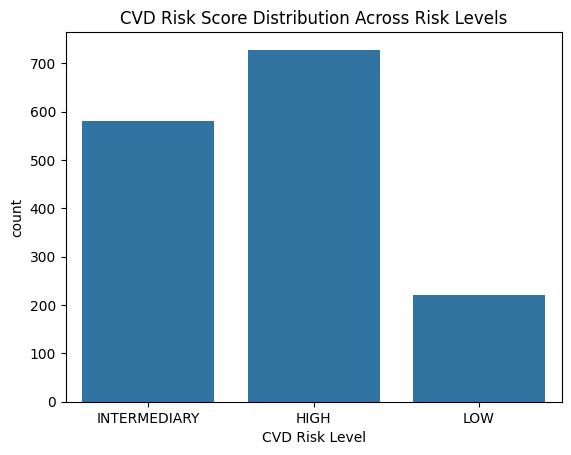

In [130]:
plt.title("CVD Risk Score Distribution Across Risk Levels")
sns.countplot(x="CVD Risk Level", data=df)

In [131]:
df["CVD Risk Level"].value_counts()

CVD Risk Level
HIGH            728
INTERMEDIARY    581
LOW             220
Name: count, dtype: int64

## 2.3 Demographic Analysis

Text(0, 0.5, 'Count')

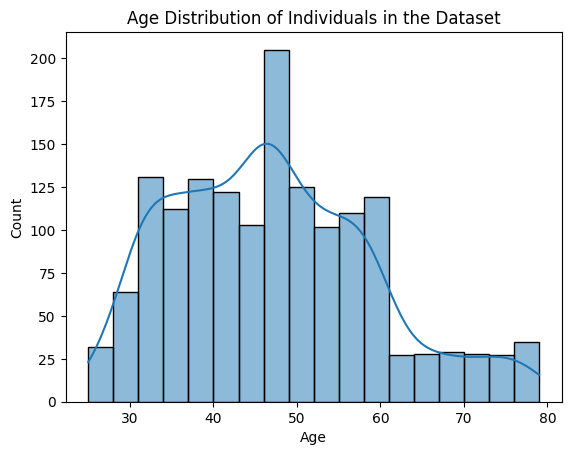

In [132]:
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution of Individuals in the Dataset")
plt.xlabel("Age")
plt.ylabel("Count")

<Axes: title={'center': 'Age Distribution Across CVD Risk Levels'}, xlabel='CVD Risk Level', ylabel='Age'>

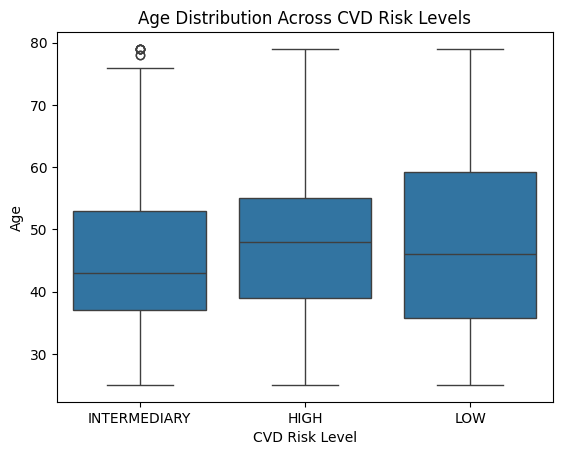

In [ ]:


sns.boxplot(x="CVD Risk Level", y="Age", data=df)

In [151]:
df["Sex"].value_counts()

Sex
F    773
M    756
Name: count, dtype: int64

<Axes: title={'center': 'Gender Distribution Across CVD Risk Levels'}, xlabel='Sex', ylabel='count'>

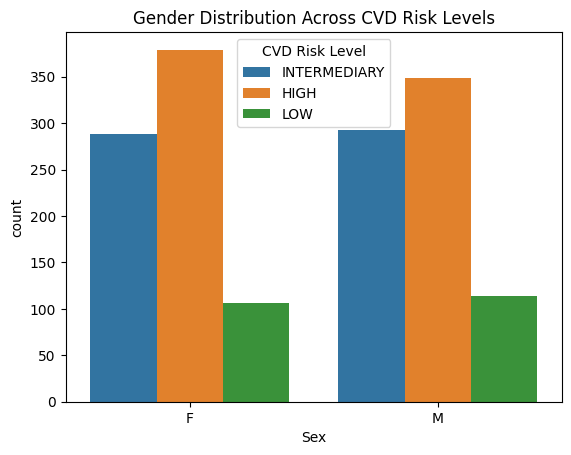

In [150]:
plt.title("Gender Distribution Across CVD Risk Levels")
sns.countplot(x="Sex", hue="CVD Risk Level", data=df)

## 2.4 Body Measurement Analysis

Text(0, 0.5, 'Count')

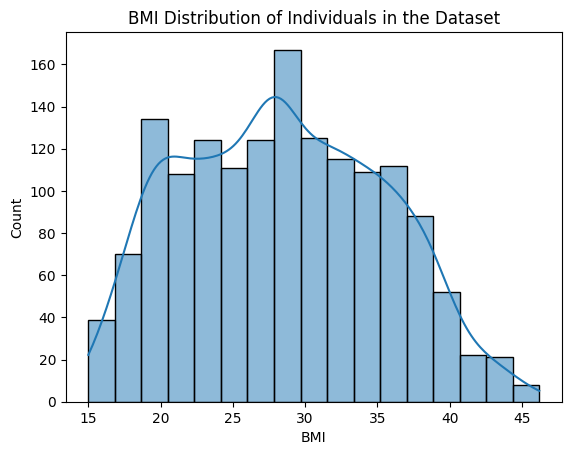

In [135]:
sns.histplot(df["BMI"], kde=True)
plt.title("BMI Distribution of Individuals in the Dataset")
plt.xlabel("BMI")
plt.ylabel("Count")

Text(0.5, 1.0, 'BMI Across CVD Risk Levels')

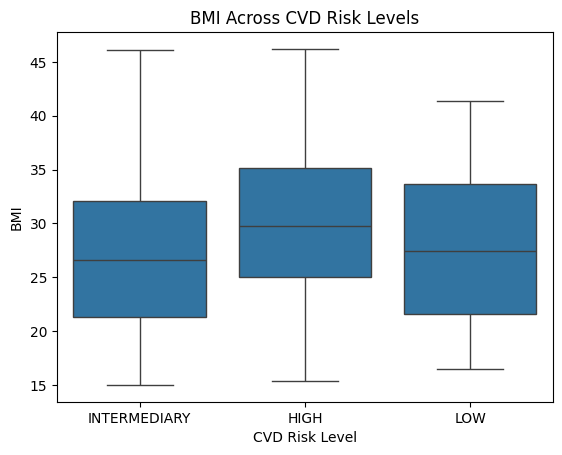

In [136]:
sns.boxplot(x="CVD Risk Level", y="BMI", data=df)
plt.title("BMI Across CVD Risk Levels")

Text(0.5, 1.0, 'BMI vs Waist-to-Height Ratio by CVD Risk Level')

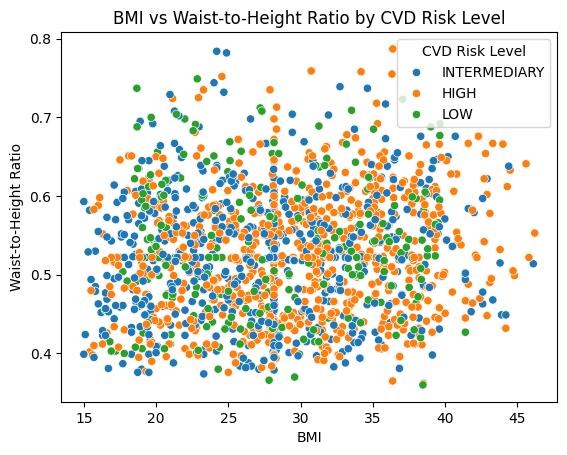

In [137]:
sns.scatterplot(
    x="BMI",
    y="Waist-to-Height Ratio",
    hue="CVD Risk Level",
    data=df
)
plt.title("BMI vs Waist-to-Height Ratio by CVD Risk Level")

Text(0.5, 1.0, 'Waist-to-Height Ratio Across CVD Risk Levels')

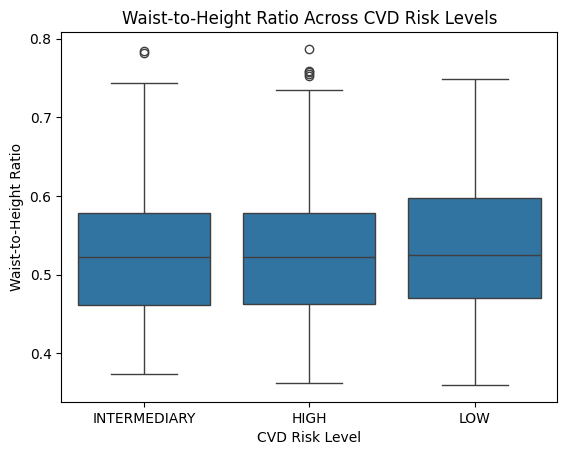

In [153]:
sns.boxplot(x="CVD Risk Level", y="Waist-to-Height Ratio", data=df)
plt.title("Waist-to-Height Ratio Across CVD Risk Levels")

## 2.5 Lifestyle and Health Factors

Text(0, 0.5, 'Proportion')

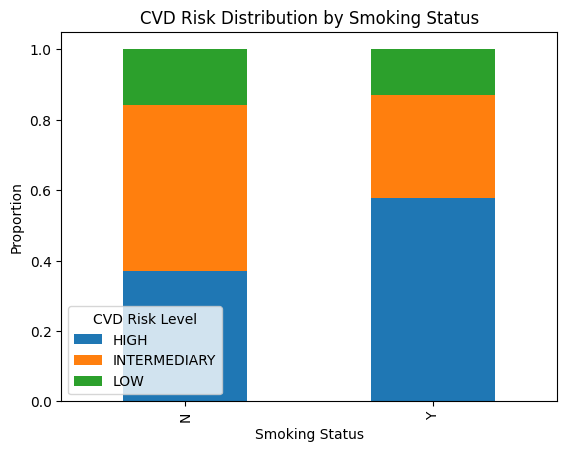

In [138]:
smoking_risk = pd.crosstab(df["Smoking Status"], df["CVD Risk Level"], normalize="index")

smoking_risk.plot(kind="bar", stacked=True)
plt.title("CVD Risk Distribution by Smoking Status")
plt.ylabel("Proportion")

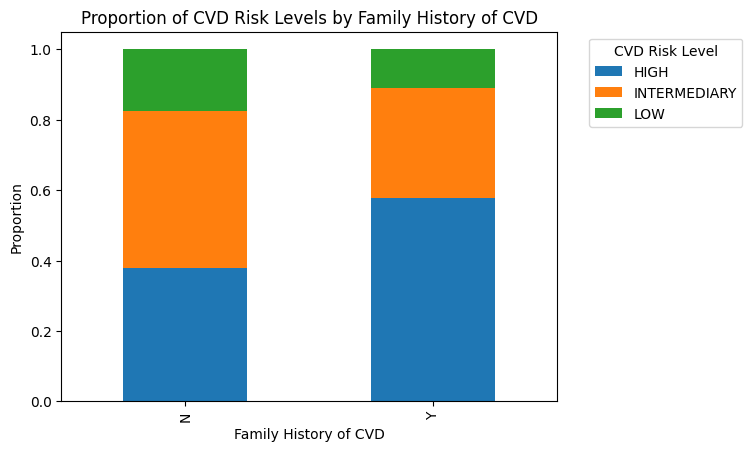

In [140]:
family_risk = pd.crosstab(
    df["Family History of CVD"],
    df["CVD Risk Level"],
    normalize="index"
)

family_risk.plot(kind="bar", stacked=True)
plt.title("Proportion of CVD Risk Levels by Family History of CVD")
plt.xlabel("Family History of CVD")
plt.ylabel("Proportion")
plt.legend(title="CVD Risk Level", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

Text(0.5, 1.0, 'CVD Risk Distribution by Diabetes Status')

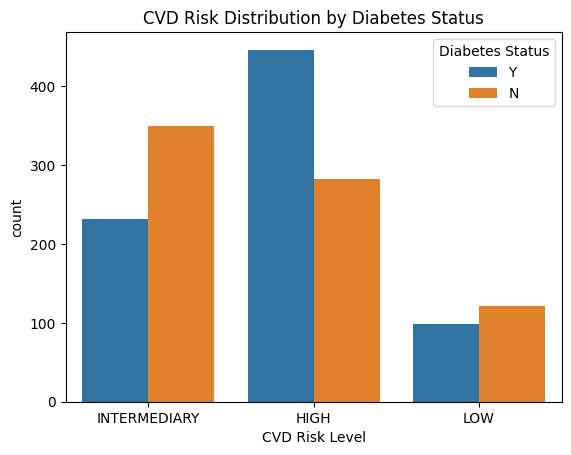

In [141]:
sns.countplot(data=df, x="CVD Risk Level", hue="Diabetes Status")
plt.title("CVD Risk Distribution by Diabetes Status")

Text(0, 0.5, 'Proportion')

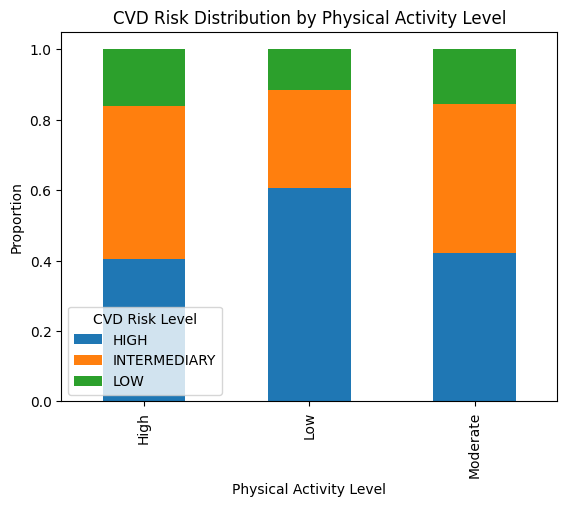

In [142]:
activity_risk = pd.crosstab(df["Physical Activity Level"], df["CVD Risk Level"], normalize="index")

activity_risk.plot(kind="bar", stacked=True)
plt.title("CVD Risk Distribution by Physical Activity Level")
plt.ylabel("Proportion")

## 2.6 Clinical indicators

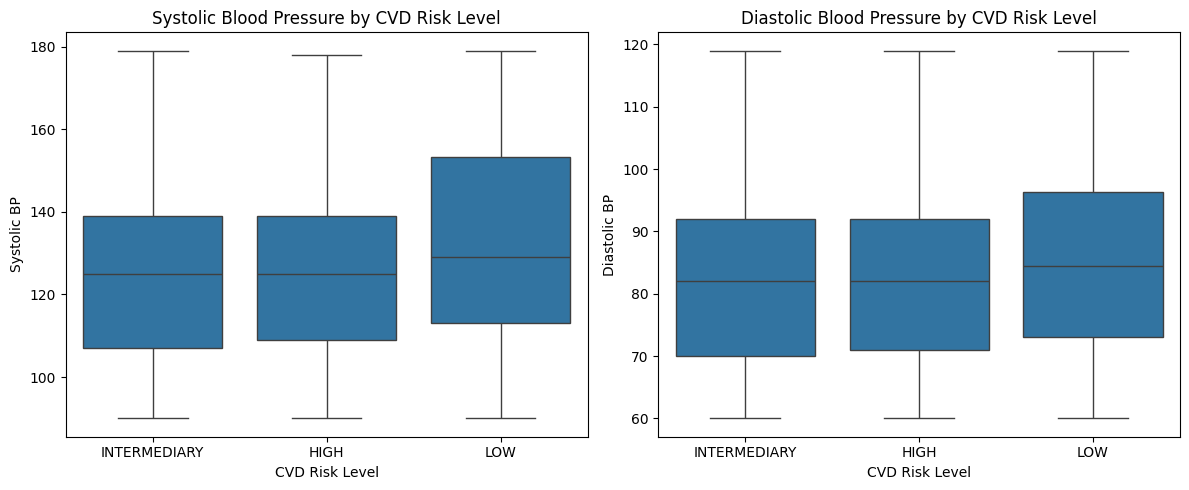

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Systolic BP
sns.boxplot(
    x="CVD Risk Level",
    y="Systolic BP",
    data=df,
    ax=axes[0]
)
axes[0].set_title("Systolic Blood Pressure by CVD Risk Level")

# Diastolic BP
sns.boxplot(
    x="CVD Risk Level",
    y="Diastolic BP",
    data=df,
    ax=axes[1]
)
axes[1].set_title("Diastolic Blood Pressure by CVD Risk Level")

plt.tight_layout()
plt.show()

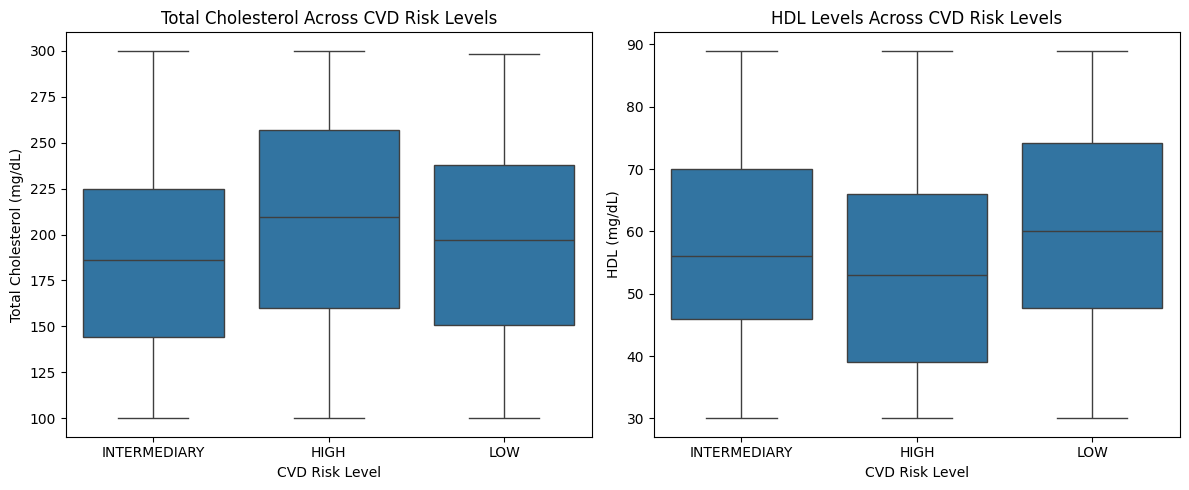

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(x="CVD Risk Level", y="Total Cholesterol (mg/dL)", data=df, ax=axes[0])
axes[0].set_title("Total Cholesterol Across CVD Risk Levels")

sns.boxplot(x="CVD Risk Level", y="HDL (mg/dL)", data=df, ax=axes[1])
axes[1].set_title("HDL Levels Across CVD Risk Levels")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Fasting Blood Sugar (mg/dL)')

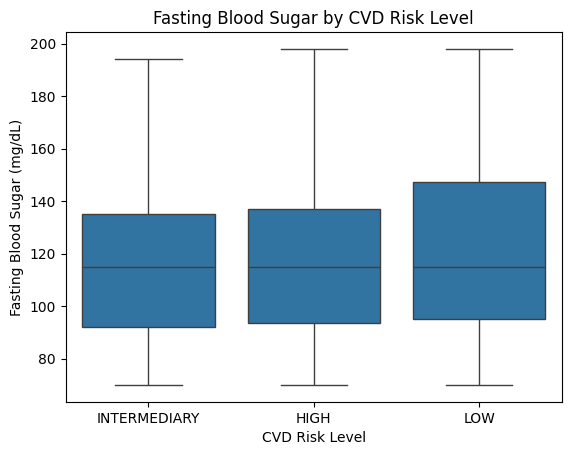

In [154]:
sns.boxplot(
    x="CVD Risk Level",
    y="Fasting Blood Sugar (mg/dL)",
    data=df
)

plt.title("Fasting Blood Sugar by CVD Risk Level")
plt.xlabel("CVD Risk Level")
plt.ylabel("Fasting Blood Sugar (mg/dL)")

## 2.7 Correlation Heatmap of Numerical Features

Text(0.5, 1.0, 'Correlation Heatmap of Numerical Features')

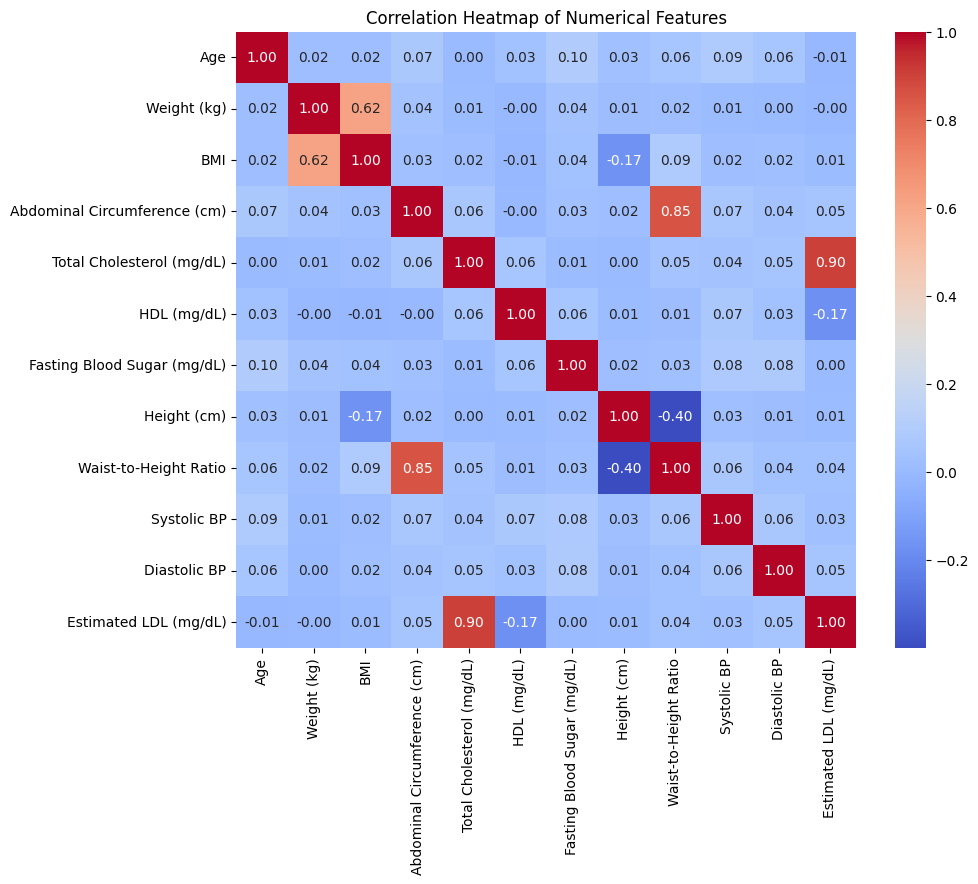

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")